In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data/raw")
# plt.style.use('default')

In [ ]:
# Pyarrow version check
import pyarrow
pyarrow.__version__

'24.0.0'

In [ ]:
# January month data loading
df_jan = pd.read_parquet(DATA_DIR / "yellow_tripdata_2023-01.parquet")
print(f"Shape: {df_jan.shape}")
df_jan.head()

Shape: (3066766, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [ ]:
df_jan.info()
# Variables types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

In [ ]:
df_jan.describe().T

# Insights about the data:

# tpep_pickup_datetime - min value 2008-12-31 23:01:42 - it shouldn't to be happened - max value 2023-02-01 00:56:53 - some data leakage from februrary
# tpep_dropoff_datetime	- 2009-01-01 14:29:11 - it shouldn't to be happened - max value 2023-02-02 09:28:47	- it would be more than a 2 days trip
# passenger count 1-9
# trip_distance 0 - 258928.15 - Two outlier - Neither of them shouldn't to be happened
# payment_type - 4 type of payments
# fare_amount - min value -900 there is some value error
# extra - min value -7,5 there is some value error
# mta_tax, mta_tax, tolls_amount, improvement_surcharge, total_amount, congestion_surcharge, airport_fee - there are negative values

,count,mean,min,25%,50%,75%,max,std
VendorID,3066766.0,1.730215,1.0,1.0,2.0,2.0,2.0,0.443848
tpep_pickup_datetime,3066766,2023-01-17 00:22:26.288164,2008-12-31 23:01:42,2023-01-09 16:21:57.250000,2023-01-17 08:42:29.500000,2023-01-24 16:26:27,2023-02-01 00:56:53,NaN
tpep_dropoff_datetime,3066766,2023-01-17 00:38:06.427874,2009-01-01 14:29:11,2023-01-09 16:37:06,2023-01-17 08:58:30.500000,2023-01-24 16:42:49,2023-02-02 09:28:47,NaN
passenger_count,2995023.0,1.362532,0.0,1.0,1.0,1.0,9.0,0.89612
trip_distance,3066766.0,3.847342,0.0,1.06,1.8,3.33,258928.15,249.583756
RatecodeID,2995023.0,1.49744,1.0,1.0,1.0,1.0,99.0,6.474767
PULocationID,3066766.0,166.398046,1.0,132.0,162.0,234.0,265.0,64.244131
DOLocationID,3066766.0,164.392631,1.0,114.0,162.0,234.0,265.0,69.943682
payment_type,3066766.0,1.194483,0.0,1.0,1.0,1.0,4.0,0.529476
fare_amount,3066766.0,18.367069,-900.0,8.6,12.8,20.5,1160.1,17.807822


In [ ]:
# How many values are missing
df_jan.count()

VendorID                 3066766
tpep_pickup_datetime     3066766
tpep_dropoff_datetime    3066766
passenger_count          2995023
trip_distance            3066766
RatecodeID               2995023
store_and_fwd_flag       2995023
PULocationID             3066766
DOLocationID             3066766
payment_type             3066766
fare_amount              3066766
extra                    3066766
mta_tax                  3066766
tip_amount               3066766
tolls_amount             3066766
improvement_surcharge    3066766
total_amount             3066766
congestion_surcharge     2995023
airport_fee              2995023
dtype: int64

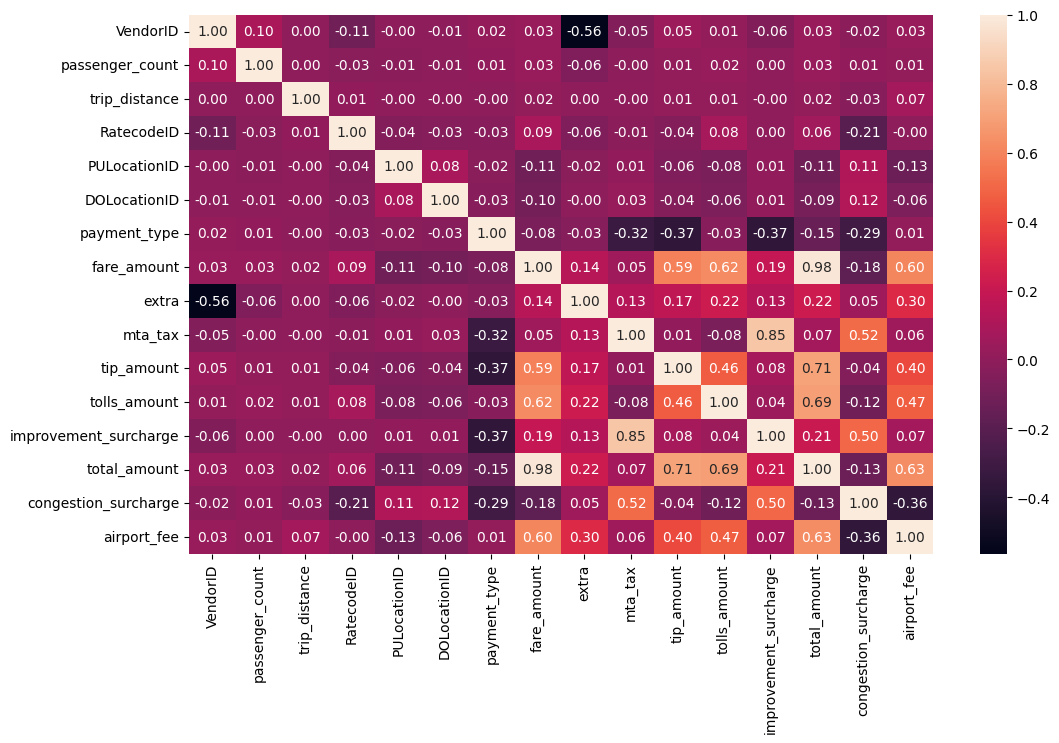

In [ ]:
# Correlation matrix visualization
corr_matrix = df_jan.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(12, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.show()

In [ ]:
# Calculating the trip time
df_jan['tpep_trip_duration'] = df_jan['tpep_dropoff_datetime'] - df_jan['tpep_pickup_datetime']
df_jan["tpep_trip_duration"].mean()

Timedelta('0 days 00:15:40.139710')

<Axes: xlabel='trip_distance', ylabel='tip_amount'>

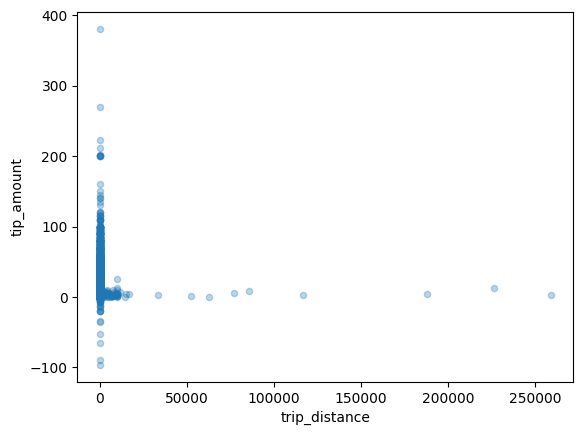

In [ ]:
# Relationship between tip_amount and trip_distance
df_jan.plot(kind="scatter", x="trip_distance", y="tip_amount", alpha=0.3)

### Gaining more insight from the columns

In [10]:
df_jan["VendorID"].value_counts()

VendorID
2    2239399
1     827367
Name: count, dtype: int64

In [11]:
df_jan["passenger_count"].value_counts().sort_values(ascending=True)

passenger_count
9.0          1
7.0          6
8.0         13
6.0      28124
5.0      42681
0.0      51164
4.0      53745
3.0     106353
2.0     451536
1.0    2261400
Name: count, dtype: int64

In [12]:
df_jan["trip_distance"].value_counts().sort_values(ascending=False)

trip_distance
0.00        45862
1.00        43827
0.90        43473
1.10        42578
0.80        41801
            ...  
2384.32         1
4144.26         1
4268.87         1
3140.87         1
52042.30        1
Name: count, Length: 4387, dtype: int64

In [13]:
df_jan["RatecodeID"].value_counts()

RatecodeID
1.0     2839305
2.0      114239
5.0       15043
99.0      13106
3.0        8958
4.0        4366
6.0           6
Name: count, dtype: int64

In [14]:
df_jan["store_and_fwd_flag"].value_counts()

store_and_fwd_flag
N    2975020
Y      20003
Name: count, dtype: int64

In [15]:
df_jan["PULocationID"].value_counts()

PULocationID
132    160030
237    148074
236    138391
161    135417
186    109227
        ...  
111         2
184         2
187         2
199         2
58          2
Name: count, Length: 257, dtype: int64

In [16]:
df_jan["DOLocationID"].value_counts()

DOLocationID
236    146348
237    132364
161    116149
230     89878
170     88783
        ...  
187        17
84         16
204        14
99          5
105         1
Name: count, Length: 261, dtype: int64

In [17]:
df_jan["payment_type"].value_counts()

payment_type
1    2411462
2     532241
0      71743
4      33297
3      18023
Name: count, dtype: int64

In [18]:
df_jan["fare_amount"].value_counts().sort_values(ascending=False)

fare_amount
8.60     149461
9.30     146821
7.90     146075
10.00    143521
7.20     139156
          ...  
58.38         1
49.58         1
96.43         1
52.31         1
58.25         1
Name: count, Length: 6873, dtype: int64

In [23]:
df_jan[df_jan['fare_amount'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,tpep_trip_duration
132,2,2023-01-01 00:28:29,2023-01-01 00:31:03,1.0,0.42,1.0,N,233,229,4,-5.10,-1.0,-0.5,0.00,0.0,-1.0,-10.10,-2.5,0.0,0 days 00:02:34
263,2,2023-01-01 00:20:18,2023-01-01 00:27:56,2.0,1.19,1.0,N,142,50,4,-9.30,-1.0,-0.5,0.00,0.0,-1.0,-14.30,-2.5,0.0,0 days 00:07:38
324,2,2023-01-01 00:52:22,2023-01-01 01:14:03,1.0,4.89,1.0,N,238,167,4,-25.40,-1.0,-0.5,0.00,0.0,-1.0,-30.40,-2.5,0.0,0 days 00:21:41
620,2,2023-01-01 00:06:39,2023-01-01 00:10:02,1.0,0.52,1.0,N,237,237,2,-5.10,-1.0,-0.5,0.00,0.0,-1.0,-10.10,-2.5,0.0,0 days 00:03:23
923,2,2023-01-01 00:34:39,2023-01-01 00:40:25,2.0,0.85,1.0,N,79,113,4,-7.20,-1.0,-0.5,0.00,0.0,-1.0,-12.20,-2.5,0.0,0 days 00:05:46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3061096,2,2023-01-29 02:51:38,2023-01-29 02:53:46,NaN,0.00,NaN,None,255,255,0,-24.89,0.0,0.5,3.34,0.0,1.0,-20.05,NaN,NaN,0 days 00:02:08
3061326,2,2023-01-29 06:02:00,2023-01-29 06:03:00,NaN,0.17,NaN,None,263,263,0,-43.98,0.0,0.5,3.33,0.0,1.0,-36.65,NaN,NaN,0 days 00:01:00
3062459,2,2023-01-29 20:35:00,2023-01-29 20:42:00,NaN,0.06,NaN,None,48,48,0,-54.10,0.0,0.5,5.78,0.0,1.0,-44.32,NaN,NaN,0 days 00:07:00
3064192,2,2023-01-30 20:02:00,2023-01-30 20:10:00,NaN,0.67,NaN,None,265,265,0,-103.61,0.0,0.5,14.59,0.0,1.0,-87.52,NaN,NaN,0 days 00:08:00


In [20]:
df_jan['extra'].value_counts().sort_values(ascending=False)

extra
0.00    1240718
2.50     763716
1.00     564096
5.00     209329
3.50     172569
         ...   
8.20          1
3.95          1
0.01          1
5.25          1
0.70          1
Name: count, Length: 68, dtype: int64

In [22]:
df_jan[df_jan['extra'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,tpep_trip_duration
132,2,2023-01-01 00:28:29,2023-01-01 00:31:03,1.0,0.42,1.0,N,233,229,4,-5.1,-1.0,-0.5,0.0,0.0,-1.0,-10.10,-2.5,0.00,0 days 00:02:34
263,2,2023-01-01 00:20:18,2023-01-01 00:27:56,2.0,1.19,1.0,N,142,50,4,-9.3,-1.0,-0.5,0.0,0.0,-1.0,-14.30,-2.5,0.00,0 days 00:07:38
324,2,2023-01-01 00:52:22,2023-01-01 01:14:03,1.0,4.89,1.0,N,238,167,4,-25.4,-1.0,-0.5,0.0,0.0,-1.0,-30.40,-2.5,0.00,0 days 00:21:41
620,2,2023-01-01 00:06:39,2023-01-01 00:10:02,1.0,0.52,1.0,N,237,237,2,-5.1,-1.0,-0.5,0.0,0.0,-1.0,-10.10,-2.5,0.00,0 days 00:03:23
923,2,2023-01-01 00:34:39,2023-01-01 00:40:25,2.0,0.85,1.0,N,79,113,4,-7.2,-1.0,-0.5,0.0,0.0,-1.0,-12.20,-2.5,0.00,0 days 00:05:46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2994678,2,2023-01-31 23:26:23,2023-01-31 23:56:00,1.0,14.02,4.0,N,138,265,4,-67.4,-6.0,-0.5,0.0,-19.3,-1.0,-95.45,0.0,-1.25,0 days 00:29:37
2994738,2,2023-01-31 23:58:56,2023-01-31 23:58:59,1.0,0.00,1.0,N,132,132,3,-3.0,-1.0,-0.5,0.0,0.0,-1.0,-6.75,0.0,-1.25,0 days 00:00:03
2994908,2,2023-01-31 23:27:31,2023-01-31 23:58:16,1.0,8.33,1.0,N,132,93,2,-42.2,-1.0,-0.5,0.0,0.0,-1.0,-45.95,0.0,-1.25,0 days 00:30:45
2994911,2,2023-01-31 23:06:10,2023-01-31 23:57:59,4.0,17.94,4.0,N,264,265,4,-98.2,-6.0,-0.5,0.0,0.0,-1.0,-109.45,-2.5,-1.25,0 days 00:51:49


In [24]:
df_jan['mta_tax'].value_counts().sort_values(ascending=False)

mta_tax
 0.50     3018062
-0.50       24501
 0.00       23421
 0.80         771
 4.00           4
 0.30           3
 1.60           1
 53.16          1
 1.09           1
 1.05           1
Name: count, dtype: int64

In [25]:
df_jan['tip_amount'].value_counts().sort_values(ascending=False)

tip_amount
 0.00     694757
 2.00     152040
 1.00     132857
 3.00      76829
 5.00      42332
           ...  
-2.09          1
 35.01         1
 62.22         1
 31.34         1
-5.78          1
Name: count, Length: 4036, dtype: int64

In [26]:
df_jan[df_jan['tip_amount'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,tpep_trip_duration
24355,2,2023-01-01 08:59:40,2023-01-01 08:59:53,1.0,0.00,1.0,N,193,193,3,-3.00,0.0,-0.5,-0.01,0.0,-1.0,-4.51,0.0,0.0,0 days 00:00:13
24656,2,2023-01-01 09:57:14,2023-01-01 09:57:19,1.0,0.00,1.0,N,193,193,3,-3.00,0.0,-0.5,-0.01,0.0,-1.0,-4.51,0.0,0.0,0 days 00:00:05
31995,2,2023-01-01 12:39:03,2023-01-01 12:39:30,1.0,0.00,1.0,N,193,193,3,-3.00,0.0,-0.5,-0.01,0.0,-1.0,-4.51,0.0,0.0,0 days 00:00:27
39378,2,2023-01-01 13:23:47,2023-01-01 13:24:10,1.0,0.00,1.0,N,193,193,3,-3.00,0.0,-0.5,-0.01,0.0,-1.0,-4.51,0.0,0.0,0 days 00:00:23
44219,2,2023-01-01 15:15:52,2023-01-01 15:16:30,1.0,0.00,1.0,N,7,7,4,-3.00,0.0,-0.5,-0.90,0.0,-1.0,-5.40,0.0,0.0,0 days 00:00:38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2968001,2,2023-01-31 18:17:34,2023-01-31 18:22:08,1.0,0.75,1.0,N,170,107,1,-6.50,-2.5,-0.5,-2.60,0.0,-1.0,-15.60,-2.5,0.0,0 days 00:04:34
2986216,2,2023-01-31 21:56:52,2023-01-31 21:56:56,1.0,0.00,5.0,N,264,264,3,-0.05,0.0,0.0,-0.08,0.0,-1.0,-1.13,0.0,0.0,0 days 00:00:04
3030890,2,2023-01-17 08:20:10,2023-01-17 08:22:00,NaN,0.37,NaN,None,137,170,0,37.25,0.0,-0.5,-3.00,0.0,0.3,31.55,NaN,NaN,0 days 00:01:50
3045965,2,2023-01-23 08:55:10,2023-01-23 08:56:00,NaN,0.18,NaN,None,170,170,0,29.22,0.0,-0.5,-3.79,0.0,0.3,22.73,NaN,NaN,0 days 00:00:50


In [27]:
df_jan['tolls_amount'].value_counts().sort_values(ascending=False)

tolls_amount
0.00     2840307
6.55      207651
12.75       1780
3.00        1602
14.75       1408
          ...   
44.75          1
15.41          1
11.10          1
17.76          1
2.80           1
Name: count, Length: 776, dtype: int64

In [28]:
df_jan[df_jan['tolls_amount'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,tpep_trip_duration
1352,2,2023-01-01 00:40:02,2023-01-01 01:07:56,1.0,9.90,1.0,N,90,67,4,-43.6,-1.0,-0.5,0.0,-6.55,-1.0,-55.15,-2.5,0.00,0 days 00:27:54
4696,2,2023-01-01 00:50:09,2023-01-01 01:24:13,1.0,23.30,1.0,N,132,220,4,-86.3,-1.0,-0.5,0.0,-6.55,-1.0,-96.60,0.0,-1.25,0 days 00:34:04
7309,2,2023-01-01 01:50:52,2023-01-01 02:10:14,1.0,11.39,1.0,N,138,32,2,-43.6,-6.0,-0.5,0.0,-6.55,-1.0,-58.90,0.0,-1.25,0 days 00:19:22
8255,2,2023-01-01 01:01:55,2023-01-01 01:40:45,2.0,8.90,5.0,N,141,265,2,-75.0,0.0,0.0,0.0,-11.75,-1.0,-90.25,-2.5,0.00,0 days 00:38:50
12387,2,2023-01-01 02:30:16,2023-01-01 02:43:20,2.0,11.23,5.0,N,265,265,4,-80.0,0.0,0.0,0.0,-15.75,-1.0,-96.75,0.0,0.00,0 days 00:13:04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2980137,2,2023-01-31 20:52:10,2023-01-31 21:18:39,1.0,14.82,2.0,N,215,246,3,-70.0,0.0,-0.5,0.0,-6.55,-1.0,-81.80,-2.5,-1.25,0 days 00:26:29
2980631,2,2023-01-31 20:39:41,2023-01-31 21:09:36,1.0,15.99,2.0,N,10,68,3,-70.0,0.0,-0.5,0.0,-6.55,-1.0,-81.80,-2.5,-1.25,0 days 00:29:55
2986786,2,2023-01-31 21:00:16,2023-01-31 21:08:31,1.0,2.10,2.0,N,75,238,2,-70.0,0.0,-0.5,0.0,-6.55,-1.0,-81.80,-2.5,-1.25,0 days 00:08:15
2991857,2,2023-01-31 22:56:37,2023-01-31 23:20:17,1.0,15.99,1.0,N,138,13,3,-60.4,-6.0,-0.5,0.0,-19.30,-1.0,-90.95,-2.5,-1.25,0 days 00:23:40


In [29]:
df_jan['improvement_surcharge'].value_counts()

improvement_surcharge
 1.0    3035371
-1.0      25117
 0.3       5269
 0.0        973
-0.3         36
Name: count, dtype: int64

In [30]:
df_jan['total_amount'].value_counts().sort_values(ascending=False)

total_amount
 16.80     48536
 12.60     45398
 21.00     37923
 15.12     26389
 15.96     26375
           ...  
 215.30        1
 297.10        1
-66.85         1
 162.68        1
 11.06         1
Name: count, Length: 15871, dtype: int64

In [31]:
df_jan[df_jan['total_amount'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,tpep_trip_duration
132,2,2023-01-01 00:28:29,2023-01-01 00:31:03,1.0,0.42,1.0,N,233,229,4,-5.10,-1.0,-0.5,0.00,0.0,-1.0,-10.10,-2.5,0.0,0 days 00:02:34
263,2,2023-01-01 00:20:18,2023-01-01 00:27:56,2.0,1.19,1.0,N,142,50,4,-9.30,-1.0,-0.5,0.00,0.0,-1.0,-14.30,-2.5,0.0,0 days 00:07:38
324,2,2023-01-01 00:52:22,2023-01-01 01:14:03,1.0,4.89,1.0,N,238,167,4,-25.40,-1.0,-0.5,0.00,0.0,-1.0,-30.40,-2.5,0.0,0 days 00:21:41
620,2,2023-01-01 00:06:39,2023-01-01 00:10:02,1.0,0.52,1.0,N,237,237,2,-5.10,-1.0,-0.5,0.00,0.0,-1.0,-10.10,-2.5,0.0,0 days 00:03:23
923,2,2023-01-01 00:34:39,2023-01-01 00:40:25,2.0,0.85,1.0,N,79,113,4,-7.20,-1.0,-0.5,0.00,0.0,-1.0,-12.20,-2.5,0.0,0 days 00:05:46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3061096,2,2023-01-29 02:51:38,2023-01-29 02:53:46,NaN,0.00,NaN,None,255,255,0,-24.89,0.0,0.5,3.34,0.0,1.0,-20.05,NaN,NaN,0 days 00:02:08
3061326,2,2023-01-29 06:02:00,2023-01-29 06:03:00,NaN,0.17,NaN,None,263,263,0,-43.98,0.0,0.5,3.33,0.0,1.0,-36.65,NaN,NaN,0 days 00:01:00
3062459,2,2023-01-29 20:35:00,2023-01-29 20:42:00,NaN,0.06,NaN,None,48,48,0,-54.10,0.0,0.5,5.78,0.0,1.0,-44.32,NaN,NaN,0 days 00:07:00
3064192,2,2023-01-30 20:02:00,2023-01-30 20:10:00,NaN,0.67,NaN,None,265,265,0,-103.61,0.0,0.5,14.59,0.0,1.0,-87.52,NaN,NaN,0 days 00:08:00


In [32]:
df_jan['congestion_surcharge'].value_counts()

congestion_surcharge
 2.5    2744268
 0.0     231037
-2.5      19718
Name: count, dtype: int64

In [33]:
df_jan['airport_fee'].value_counts()

airport_fee
 0.00    2730456
 1.25     260960
-1.25       3607
Name: count, dtype: int64